# Exemple complet du Pipeline RAG - Chat de Calais

Ce notebook montre un exemple complet d'utilisation du pipeline RAG avec HyDE et Reranking ALBERT.

**Objectif** : Démontrer le fonctionnement du système sur une question unique.

## 1. Configuration et imports

In [1]:
# Imports nécessaires
import os
from pathlib import Path
import time

# Modules du projet
import config
from albert_client import get_embeddings, get_llm
from indexer import index_documents
from rag_pipeline import rag_query
from logger import RAGLogger

# Configuration
config.VERBOSE = True  # Activer les logs détaillés
print(f"✅ Configuration chargée")
print(f"   - Mode de prompt: {config.PROMPT_MODE}")
print(f"   - HyDE activé: {config.USE_HYDE}")
print(f"   - Reranking activé: {config.USE_RERANK}")

✅ Configuration chargée
   - Mode de prompt: administratif
   - HyDE activé: True
   - Reranking activé: True


## 2. Initialisation du système

On initialise les composants nécessaires :
- Client d'embeddings ALBERT
- LLM ALBERT
- Logger SQLite
- Indexation des documents

In [2]:
# Initialiser le client d'embeddings
print("\n🔧 Initialisation des clients ALBERT...")
embeddings = get_embeddings()
print(f"   ✓ Embeddings: {config.EMBEDDINGS_MODEL}")

# Initialiser le LLM
llm = get_llm()
print(f"   ✓ LLM: {config.LLM_MODEL}")


🔧 Initialisation des clients ALBERT...
   ✓ Embeddings: embeddings-small
   ✓ LLM: albert-large


In [3]:
# Initialiser le logger
print("\n📝 Initialisation du logger...")
logger = RAGLogger(config.RAG_LOGS_DB)
print(f"   ✓ Base de logs: {config.RAG_LOGS_DB}")


📝 Initialisation du logger...
   ✓ Base de logs: ./rag_logs.db


In [4]:
# Indexer les documents
print("\n📚 Indexation des documents...")
vectorstore, retriever = index_documents(embeddings)
print(f"   ✓ Indexation terminée")


📚 Indexation des documents...
Base: c:\Users\romain.cadot\Documents\py\chat-de-calais\chroma_db_rag
Documents: ./documents

Changements:
   Nouveaux: 0
   Modifiés: 0
   Supprimés: 0
   Inchangés: 7

Aucun changement!
   ✓ Indexation terminée


## 3. Exemple de requête

Nous allons poser une question au système et observer chaque étape du pipeline.

In [ ]:
# Question d'exemple
user_query = "Que peux tu me dire de Pas-de-Calais Habitat ?"

print(f"\n{'=' * 80}")
print(f"QUESTION POSÉE")
print(f"{'=' * 80}")
print(f"\n{user_query}\n")


QUESTION POSÉE

Que peux tu me dire de Pas-de-Calais Habitat ?



## 4. Exécution du pipeline RAG

Le pipeline se décompose en 4 étapes :
1. **HyDE** : Génération d'un document hypothétique
2. **Retrieval** : Récupération de 30 documents similaires
3. **Reranking** : Rerank des documents avec ALBERT
4. **Génération** : Génération de la réponse finale

In [6]:
# Exécuter le pipeline complet
print(f"\n{'=' * 80}")
print(f"EXÉCUTION DU PIPELINE RAG")
print(f"{'=' * 80}\n")

result = rag_query(
    query=user_query,
    retriever=retriever,
    llm=llm,
    logger=logger,
    top_k=5,
    mode="technique",  # On utilise le mode technique pour cet exemple
)


EXÉCUTION DU PIPELINE RAG


Nouvelle requête (mode: technique)
Question: Que peux tu me dire de Pas-de-Calais Habitat ?

1/4: Génération HyDE...
   HyDE (mode: administratif):
   Original: Que peux tu me dire de Pas-de-Calais Habitat ?...
   Enrichi: **Document de Référence Administratif**
**Objet : Présentation de Pas-de-Calais Habitat**

**Référence :** [Votre référence interne]
**Date :** [Date de rédaction]
**Rédigé par :** [Votre nom/service]...
2/4: Retrieval (top 30)...
30 documents récupérés
3/4: Rerank (top 5)...
 Rerank: 30 docs...
 Rerank OK
5 documents après rerank
4/4: Génération de la réponse (mode: technique)...

📄 Réponse générée:
   ### **Analyse technique de Pas-de-Calais Habitat**

#### **1. Contexte et enjeux principaux**
Pas-de-Calais Habitat (PCH) est un office public de l’habitat (OPH) confronté à plusieurs défis majeurs liés à la rénovation urbaine, à la vacance des logements et à la gestion financière. Voici les points ...

📁 Sources utilisées:
   1. [0.484] .

## 5. Analyse des résultats

In [7]:
# Afficher la réponse générée
print(f"\n{'=' * 80}")
print(f"RÉPONSE GÉNÉRÉE")
print(f"{'=' * 80}\n")
print(result["answer"])


RÉPONSE GÉNÉRÉE

### **Analyse technique de Pas-de-Calais Habitat**

#### **1. Contexte et enjeux principaux**
Pas-de-Calais Habitat (PCH) est un office public de l’habitat (OPH) confronté à plusieurs défis majeurs liés à la rénovation urbaine, à la vacance des logements et à la gestion financière. Voici les points clés :

- **Perte de logements** : Dans le cadre du **NPNRU** (Nouveau Programme National de Renouvellement Urbain), PCH doit démolir ou vendre des logements, notamment dans des quartiers dégradés (Avion, Liévin, Outreau).
- **Impact financier** : Les subventions sont insuffisantes pour couvrir les coûts réels des travaux, notamment en raison de l’inflation post-crise sanitaire et guerre en Ukraine.
- **Vacance locative** : 2 000 logements vacants nécessitent des investissements pour être remis en location, en concurrence avec d’autres bailleurs (ex. : ERBM).
- **Absence de vision globale** : PCH n’a pas encore de plan stratégique clair pour prioriser les travaux et investi

In [8]:
# Afficher les statistiques du pipeline
print(f"\n{'=' * 80}")
print(f"STATISTIQUES DU PIPELINE")
print(f"{'=' * 80}\n")

print(f"📊 Métriques:")
print(f"   - Documents récupérés (retrieval): {result['n_docs_retrieved']}")
print(f"   - Documents finaux (après rerank): {result['n_docs_final']}")
print(f"   - Temps d'exécution: {result['execution_time']:.2f}s")
print(f"   - Mode de prompt: {result['prompt_mode']}")
print(f"   - Erreur: {result['error'] or 'Aucune'}")


STATISTIQUES DU PIPELINE

📊 Métriques:
   - Documents récupérés (retrieval): 30
   - Documents finaux (après rerank): 5
   - Temps d'exécution: 65.70s
   - Mode de prompt: technique
   - Erreur: Aucune


In [9]:
# Afficher les sources avec scores
print(f"\n{'=' * 80}")
print(f"SOURCES CONSULTÉES (avec scores de reranking)")
print(f"{'=' * 80}\n")

for i, (source, score) in enumerate(zip(result["sources"], result["rerank_scores"]), 1):
    source_name = Path(source).name
    score_str = f"{score:.4f}" if score is not None else "N/A"
    print(f"{i}. [{score_str}] {source_name}")


SOURCES CONSULTÉES (avec scores de reranking)

1. [0.4842] note_Préfet situation PDCH.odt
2. [0.2415] note_Préfet situation PDCH.odt
3. [0.0606] Fiche Préfet Bilaterale 14sept2023 SHRU.odt
4. [0.0147] 20230103_Note_amenagement_commercial_loi_CR.odt
5. [0.0111] Fiche Préfet Bilaterale 14sept2023 SHRU.odt


## 6. Détails des documents reranked

Examinons le contenu des documents finaux utilisés pour générer la réponse.

In [10]:
# Afficher les extraits des documents reranked
if "reranked_docs" in result and result["reranked_docs"]:
    print(f"\n{'=' * 80}")
    print(f"EXTRAITS DES DOCUMENTS UTILISÉS")
    print(f"{'=' * 80}\n")

    for i, doc in enumerate(result["reranked_docs"], 1):
        source = doc.metadata.get("source", "N/A")
        score = doc.metadata.get("rerank_score", None)
        content_preview = doc.page_content[:300] + "..."

        print(f"\n--- Document {i} ---")
        print(f"Source: {Path(source).name}")
        print(f"Score de rerank: {score:.4f}" if score else "Score: N/A")
        print(f"\nExtrait:")
        print(content_preview)
        print(f"\n{'-' * 80}")
else:
    print("⚠️ Détails des documents non disponibles")


EXTRAITS DES DOCUMENTS UTILISÉS


--- Document 1 ---
Source: note_Préfet situation PDCH.odt
Score de rerank: 0.4842

Extrait:
Pas-de-Calais Habitat va donc perdre beaucoup de logements dans le cadre du NPNRU, même si pour certains projets, la vacance était importante du fait de l'état de dégradation des bâtiments (Avion, Liévin, Outreau,...).
L'impact financier de ces projets est d’autant plus important pour l’organisme su...

--------------------------------------------------------------------------------

--- Document 2 ---
Source: note_Préfet situation PDCH.odt
Score de rerank: 0.2415

Extrait:
Ainsi, une subvention de 4M€ a été délivrée en 2023 par le Département, fléchée sur la lutte contre la vacance de longue durée et conditionnée à une meilleure rigueur de gestion. Elle est a priori de 5M€ en 2024.
Pourtant, l’organisme ne semble pas disposer d’une vision claire et globale de l’ensemb...

--------------------------------------------------------------------------------

--- Doc

## 7. Visualisation des scores de reranking

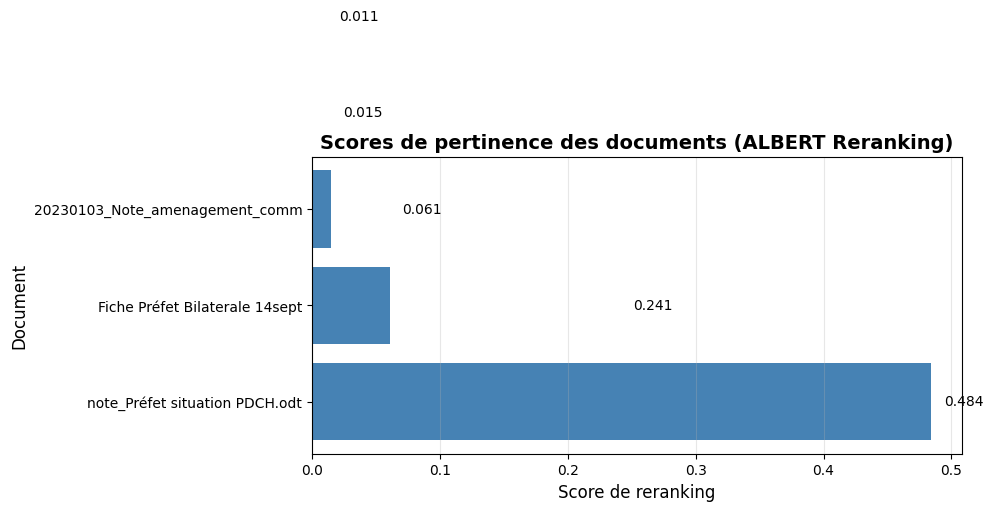

In [11]:
# Visualiser les scores avec matplotlib
import matplotlib.pyplot as plt

if result["rerank_scores"] and any(s is not None for s in result["rerank_scores"]):
    scores = [s for s in result["rerank_scores"] if s is not None]
    doc_names = [
        Path(s).name[:30]
        for s, sc in zip(result["sources"], result["rerank_scores"])
        if sc is not None
    ]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(doc_names, scores, color="steelblue")
    ax.set_xlabel("Score de reranking", fontsize=12)
    ax.set_ylabel("Document", fontsize=12)
    ax.set_title(
        "Scores de pertinence des documents (ALBERT Reranking)",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(axis="x", alpha=0.3)

    # Ajouter les valeurs sur les barres
    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.01, i, f"{score:.3f}", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Pas de scores de reranking disponibles pour visualisation")

## 8. Comparaison des modes de prompt

Testons la même question avec les 3 modes de prompt disponibles.

In [12]:
# Tester les 3 modes
modes = ["administratif", "technique", "créatif"]
results_by_mode = {}

print(f"\n{'=' * 80}")
print(f"COMPARAISON DES MODES DE PROMPT")
print(f"{'=' * 80}\n")

for mode in modes:
    print(f"\n🎭 Mode: {mode.upper()}")
    print("-" * 80)

    result_mode = rag_query(
        query=user_query,
        retriever=retriever,
        llm=llm,
        logger=None,  # Ne pas logger pour éviter les duplications
        top_k=5,
        mode=mode,
    )

    results_by_mode[mode] = result_mode

    # Afficher aperçu de la réponse
    answer_preview = result_mode["answer"][:300] + "..."
    print(f"\nRéponse ({result_mode['execution_time']:.2f}s):")
    print(answer_preview)

print(f"\n{'=' * 80}")


COMPARAISON DES MODES DE PROMPT


🎭 Mode: ADMINISTRATIF
--------------------------------------------------------------------------------

Nouvelle requête (mode: administratif)
Question: Que peux tu me dire de Pas-de-Calais Habitat ?

1/4: Génération HyDE...
   HyDE (mode: administratif):
   Original: Que peux tu me dire de Pas-de-Calais Habitat ?...
   Enrichi: **Document de Référence**
**Objet : Présentation de Pas-de-Calais Habitat**

**Référence :** [À compléter]
**Date :** [À compléter]
**Destinataire :** [À compléter]
**Émetteur :** [Service ou administ...
2/4: Retrieval (top 30)...
30 documents récupérés
3/4: Rerank (top 5)...
 Rerank: 30 docs...
 Rerank OK
5 documents après rerank
4/4: Génération de la réponse (mode: administratif)...

📄 Réponse générée:
   **Réponse sur Pas-de-Calais Habitat**

Pas-de-Calais Habitat (PCH) est un office public de l'habitat (OPH) confronté à des défis majeurs liés à la rénovation urbaine, à la gestion de son parc et à sa viabilité financière. V

## 9. Statistiques globales des logs

Consultons les statistiques de toutes les requêtes enregistrées.

In [13]:
# Récupérer les statistiques
stats = logger.get_stats()

print(f"\n{'=' * 80}")
print(f"STATISTIQUES GLOBALES DES LOGS")
print(f"{'=' * 80}\n")

print(f"📊 Requêtes:")
print(f"   - Total: {stats['total_queries']}")
print(f"   - Erreurs: {stats['error_queries']}")
print(f"   - Taux de succès: {stats['success_rate']:.1f}%")

if stats["avg_execution_time"]:
    print(f"\n⏱️ Performances:")
    print(f"   - Temps moyen: {stats['avg_execution_time']:.2f}s")

if stats["avg_docs_retrieved"]:
    print(f"\n📚 Documents:")
    print(f"   - Docs moyens récupérés: {stats['avg_docs_retrieved']:.1f}")

if stats["mode_distribution"]:
    print(f"\n🎭 Distribution des modes:")
    for mode, count in stats["mode_distribution"].items():
        print(f"   - {mode}: {count} requêtes")

# Feedback utilisateur
print(f"\n💬 Feedback utilisateur:")
print(f"   - Thumbs up: {stats['thumbs_up_count']}")
print(f"   - Thumbs down: {stats['thumbs_down_count']}")
print(f"   - Taux de feedback: {stats['feedback_rate']:.1f}%")


STATISTIQUES GLOBALES DES LOGS

📊 Requêtes:
   - Total: 104
   - Erreurs: 13
   - Taux de succès: 87.5%

⏱️ Performances:
   - Temps moyen: 6.44s

📚 Documents:
   - Docs moyens récupérés: 11.6

🎭 Distribution des modes:
   - administratif: 45 requêtes
   - créatif: 32 requêtes
   - technique: 27 requêtes

💬 Feedback utilisateur:
   - Thumbs up: 44
   - Thumbs down: 11
   - Taux de feedback: 52.9%


## Conclusion

Ce notebook a démontré :

1. ✅ **Initialisation** du système RAG avec ALBERT
2. ✅ **Indexation** des documents dans ChromaDB
3. ✅ **Pipeline complet** : HyDE → Retrieval → Reranking → Génération
4. ✅ **Analyse des résultats** avec sources et scores
5. ✅ **Comparaison des modes** de prompt
6. ✅ **Logging et traçabilité** complète

### Points clés

- Le **HyDE** améliore la qualité du retrieval en générant un document hypothétique
- Le **reranking ALBERT** affine la pertinence des documents récupérés
- Les **modes de prompt** adaptent le ton et la structure de la réponse
- Le **système de logging** permet un suivi complet des performances